In [ ]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.spatial import cKDTree
from zhiyi.analysis.SE_analysis import get_site_index 
print("done")


done


In [ ]:

SCRIP_file  = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

se_base_files = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
start_date = datetime.date(2018, 6, 22)
end_date = datetime.date(2018, 7, 15)
se_files = []
current = start_date
while current <= end_date:
    MM = current.strftime("%m")
    DD = current.strftime("%d")
    file_path = se_base_files.replace("MM", MM).replace("DD", DD)

    if os.path.exists(file_path):
        se_files.append(file_path)
    else:
        print(f"Warning: File not found - {file_path}, skipping this file.")
    current += datetime.timedelta(days=1)
ds_uk = xr.open_mfdataset(se_files, combine="by_coords")

se_base_files_nobb= "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_NOBB_month6/atm/hist/MUSICA_production3.2_NOBB_month6.cam.h2.2018-MM-DD-03600.nc"
start_date_nobb = datetime.date(2018, 6, 22)
end_date_nobb = datetime.date(2018, 7, 2)
se_files_nobb = []
current_nobb = start_date_nobb
while current_nobb <= end_date_nobb:
    MM = current_nobb.strftime("%m")
    DD = current_nobb.strftime("%d")
    file_path_nobb = se_base_files_nobb.replace("MM", MM).replace("DD", DD)

    if os.path.exists(file_path_nobb):
        se_files_nobb.append(file_path_nobb)
    else:
        print(f"Warning: File not found - {file_path_nobb}, skipping this file.")
    current_nobb += datetime.timedelta(days=1)
ds_uk_nobb = xr.open_mfdataset(se_files_nobb, combine="by_coords")

print("Datasets loaded!")

city_lonlat = {
    'Manchester':[360 - 2.237881, 53.481520],
    'Liverpool':[360 - 2.960989, 53.424225],
    'Sheffield':[360 - 1.455815, 53.404950],
    'Birmingham':[360 - 1.874978, 52.476145]}

Index_lonlat = {}
for city in city_lonlat:
    lon360, lat = city_lonlat[city]
    Index_lonlat[city] = get_site_index(
        lon360, lat,
        scrip_file=SCRIP_file)

print('done')

Datasets loaded!
done


In [ ]:

cities = [
          'Manchester', 
          'Sheffield', 
          'Liverpool', 
          'Birmingham']
vars_model = {'O3': 'O3'}

lon360     = ds_uk  ['lon'].isel(time=0).values
lat        = ds_uk  ['lat'].isel(time=0).values
lon180     = (lon360 + 180) % 360 - 180

lon360_nb  = ds_uk_nobb['lon'].isel(time=0).values
lat_nb     = ds_uk_nobb['lat'].isel(time=0).values
lon180_nb  = (lon360_nb + 180) % 360 - 180

tree     = cKDTree(np.vstack([lat, lon180 ]).T)
tree_nbb = cKDTree(np.vstack([lat_nb, lon180_nb]).T)
time_bb   = pd.to_datetime(ds_uk.time.values)
time_nobb = pd.to_datetime(ds_uk_nobb.time.values)

stats = {city: {} for city in cities}
print('done')
k_cover = 9

for city in cities:
    lon_c360, lat_c = city_lonlat[city]
    lon_c180 = (lon_c360 + 180) % 360 - 180
    _, idx_bb  = tree    .query([lat_c, lon_c180], k=k_cover)
    _, idx_nb  = tree_nbb.query([lat_c, lon_c180], k=k_cover)
    stats[city] = {}
    for name, var in vars_model.items():
        data_bb   = ds_uk   [var].values
        data_nobb = ds_uk_nobb[var].values
        if name == 'AOD':
            arr_bb   = data_bb[:, idx_bb] 
            arr_nobb = data_nobb[:, idx_nb]
        elif name == 'O3':
            o3_bb   = data_bb[:, -1, idx_bb]   * 1e9 
            o3_nobb = data_nobb[:, -1, idx_nb] * 1e9
            t_bb_local   = (pd.to_datetime(time_bb)
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))
            t_nobb_local = (pd.to_datetime(time_nobb)
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))

            df_bb   = pd.DataFrame(o3_bb, index=t_bb_local)
            df_nobb = pd.DataFrame(o3_nobb, index=t_nobb_local )
            df_bb   = df_bb.asfreq('h')
            df_nobb = df_nobb.asfreq('h')
            m8_bb   = df_bb.rolling(window=8, min_periods=8).mean()
            m8_nobb = df_nobb.rolling(window=8, min_periods=8).mean()
            mda8_bb   = m8_bb.resample('D').max()
            mda8_nobb = m8_nobb.resample('D').max()

            days = mda8_bb.index.intersection(mda8_nobb.index)
            mda8_bb   = mda8_bb.loc[days]
            mda8_nobb = mda8_nobb.loc[days]
            time_mda8_bb  = mda8_bb.index
            time_mda8_nobb= mda8_nobb.index    
            arr_bb   = mda8_bb.values
            arr_nobb = mda8_nobb.values          
        else:
            arr_bb   = data_bb[:, -1, idx_bb]   * 1e9
            arr_nobb = data_nobb[:, -1, idx_nb] * 1e9

        stats[city][name] = {
            # 'min_bb':    np.nanmin(arr_bb,   axis=1),
            # 'max_bb':    np.nanmax(arr_bb,   axis=1),
            'mean_bb':   np.nanmean(arr_bb,  axis=1),
            # 'min_nobb':  np.nanmin(arr_nobb, axis=1),
            # 'max_nobb':  np.nanmax(arr_nobb, axis=1),
            'mean_nobb': np.nanmean(arr_nobb,axis=1),}


done


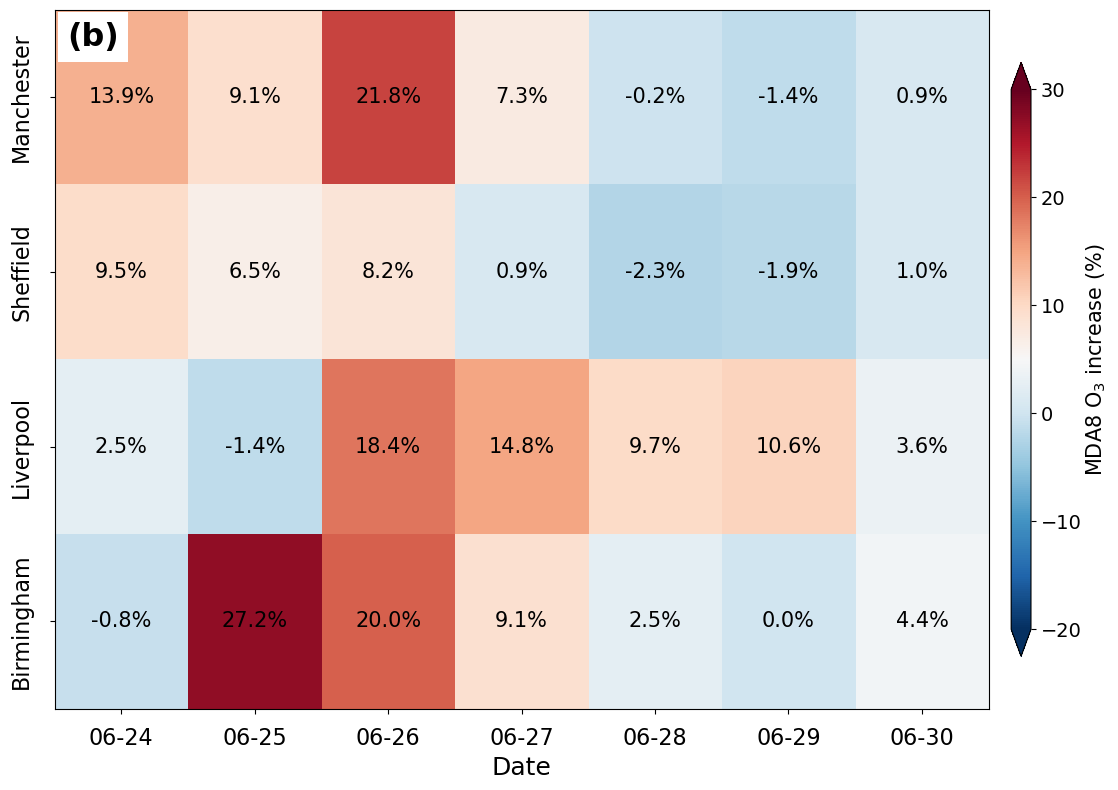

In [ ]:

dates = pd.DatetimeIndex(time_mda8_bb)
df_pct = pd.DataFrame(index=cities, columns=dates)

for city in cities:
    s = stats[city]['O3']
    mean_bb   = np.asarray(s['mean_bb'])
    mean_nobb = np.asarray(s['mean_nobb'])
    pct_mean  = 100.0 * (mean_bb - mean_nobb) / mean_nobb
    df_pct.loc[city] = pct_mean
df_pct = df_pct.astype(float)

start_date = "2018-06-24"
end_date   = "2018-06-30"
df_pct = df_pct.loc[:, start_date:end_date]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(df_pct.values,aspect='auto',cmap='RdBu_r', vmin=-20, vmax=30)
ax.set_yticks(np.arange(len(cities)))
ax.set_yticklabels(cities, fontsize=16, rotation=90, va='center')
ax.tick_params(axis='y', pad=12)
ax.set_xticks(np.arange(len(df_pct.columns)))
ax.set_xticklabels([d.strftime('%m-%d') for d in df_pct.columns], ha='center', fontsize=16)
ax.tick_params(axis='x', pad=10)
ax.set_xlabel("Date", fontsize=18)

cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.85, extend='both', aspect=30)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("MDA8 O$_3$ increase (%)", fontsize=15, labelpad=2)

for i, city in enumerate(df_pct.index):
    for j, d in enumerate(df_pct.columns):
        val = df_pct.loc[city, d]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}%", 
                    ha='center', va='center',
                    fontsize=15,)

ax.text(0.0135, 0.983, '(b)', 
        transform=ax.transAxes,
        fontsize=23, va='top', ha='left', weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.3'))

plt.tight_layout()


